In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import genextreme as gev

from unseen import fileio
from unseen import process_utils
from unseen import eva
from unseen import stability
from unseen import independence
from unseen import bias_correction
from unseen import time_utils
from unseen import moments
from unseen import similarity

In [2]:
var = 'tasmax'
baseline_period = ['1970-01-01', '2018-12-30']

In [3]:
def likelihood(data, event):
    """Calculate event likelihood"""

    shape, loc, scale = eva.fit_gev(data)
    probability = gev.sf(event, shape, loc=loc, scale=scale)
    return_period = 1. / probability
    percentile = (1 - probability) * 100
    print(f'{return_period:.0f} year return period')
    print(f'{percentile:.2f}% percentile')

    return shape, loc, scale

In [4]:
def detrend_model(da_model_stacked, pivot_year=2021):
    """Apply reference year detrending to model data.

    Reference: Atkins et al, 2025, doi:10.1038/s43247-025-02802-3
    """

    linear_fit = np.polyfit(da_model_stacked.time.dt.year.values, da_model_stacked.values, 1)
    print(linear_fit)
    linear_data = np.polyval(linear_fit, np.unique(da_model_stacked.time.dt.year.values))
    value_year_pairs = np.column_stack((da_model_stacked.values, da_model_stacked.time.dt.year.values))
    detrended_data = []
    pivot_value = np.polyval(linear_fit, pivot_year)
    for value, year in value_year_pairs:
        af = pivot_value - np.polyval(linear_fit, year)
        detrended_value = value + af
        detrended_data.append(detrended_value)
    detrended_data = np.array(detrended_data)
    da_model_detrended_stacked = da_model_stacked * 0 + detrended_data
    da_model_detrended_stacked.attrs = da_model_stacked.attrs
    da_model_detrended = da_model_detrended_stacked.unstack()

    return da_model_detrended, da_model_detrended_stacked, linear_data


def detrend_obs(da_obs, pivot_year=2021):
    """Apply reference year detrending to observations.

    Reference: Atkins et al, 2025, doi:10.1038/s43247-025-02802-3
    """

    linear_fit = np.polyfit(da_obs.time.dt.year.values, da_obs.values, 1)
    print(linear_fit)
    linear_data = np.polyval(linear_fit, da_obs.time.dt.year.values)
    pivot_index = int(np.where(da_obs.time.dt.year.values == pivot_year)[0][0])
    linear_anomaly = linear_data[pivot_index] - linear_data 
 
    da_obs_detrended = da_obs + linear_anomaly
    da_obs_detrended.attrs = da_obs.attrs

    return da_obs_detrended, linear_data

## Read observations

In [5]:
obs_file = '/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/txx_ERA5_1940-2025_annual_PNW.nc'

In [6]:
obs_ds = fileio.open_dataset(obs_file)
obs_ds = obs_ds.dropna("time")

In [7]:
obs_max_event = obs_ds["tasmax"].values.max()
print(obs_max_event)

39.51474681653524


In [8]:
obs_da_detrended, obs_linear_data = detrend_obs(obs_ds[var])

[ 3.44858526e-02 -3.76482063e+01]


In [9]:
obs_ds_baseline = time_utils.select_time_period(obs_ds, baseline_period)

In [10]:
obs_da_baseline_detrended = time_utils.select_time_period(obs_da_detrended, baseline_period)

## Read (and test) model data

In [11]:
model_ds = fileio.open_dataset('/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/txx_CanESM5-dcppA-hindcast_196101-201701_annual_PNW.nc')

In [12]:
model_ds = model_ds.compute()
model_ds

<xarray.Dataset> Size: 552kB
Dimensions:     (init_date: 57, ensemble: 20, lead_time: 10)
Coordinates:
    event_time  (init_date, ensemble, lead_time) <U10 456kB '1961-09-19' ... ...
  * ensemble    (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
  * lead_time   (lead_time) int64 80B 0 1 2 3 4 5 6 7 8 9
  * init_date   (init_date) object 456B 1961-01-01 00:00:00 ... 2017-01-01 00...
    time        (lead_time, init_date) object 5kB 1961-01-01 00:00:00 ... 202...
Data variables:
    tasmax      (init_date, ensemble, lead_time) float64 91kB 29.43 ... 33.45
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          d2a-asm-e01
    CCCma_pycmor_hash:           13db8596c37129e414cad7ae31f2927ca8f5dd39
    CCCma_runid:                 d2a196101e01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1961:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/25f98021-2584-4a17-9c4d-f9aa8aa...
    variable_id:                 tasmax
    variant_label:               r1i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/xstatstests/scipy.py:246: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  outputs = func(args, **scipy_kwargs)
/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/xstatstests/scipy.py:246: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  outputs = func(args, **scipy_kwargs)


#### Stability and stationarity

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


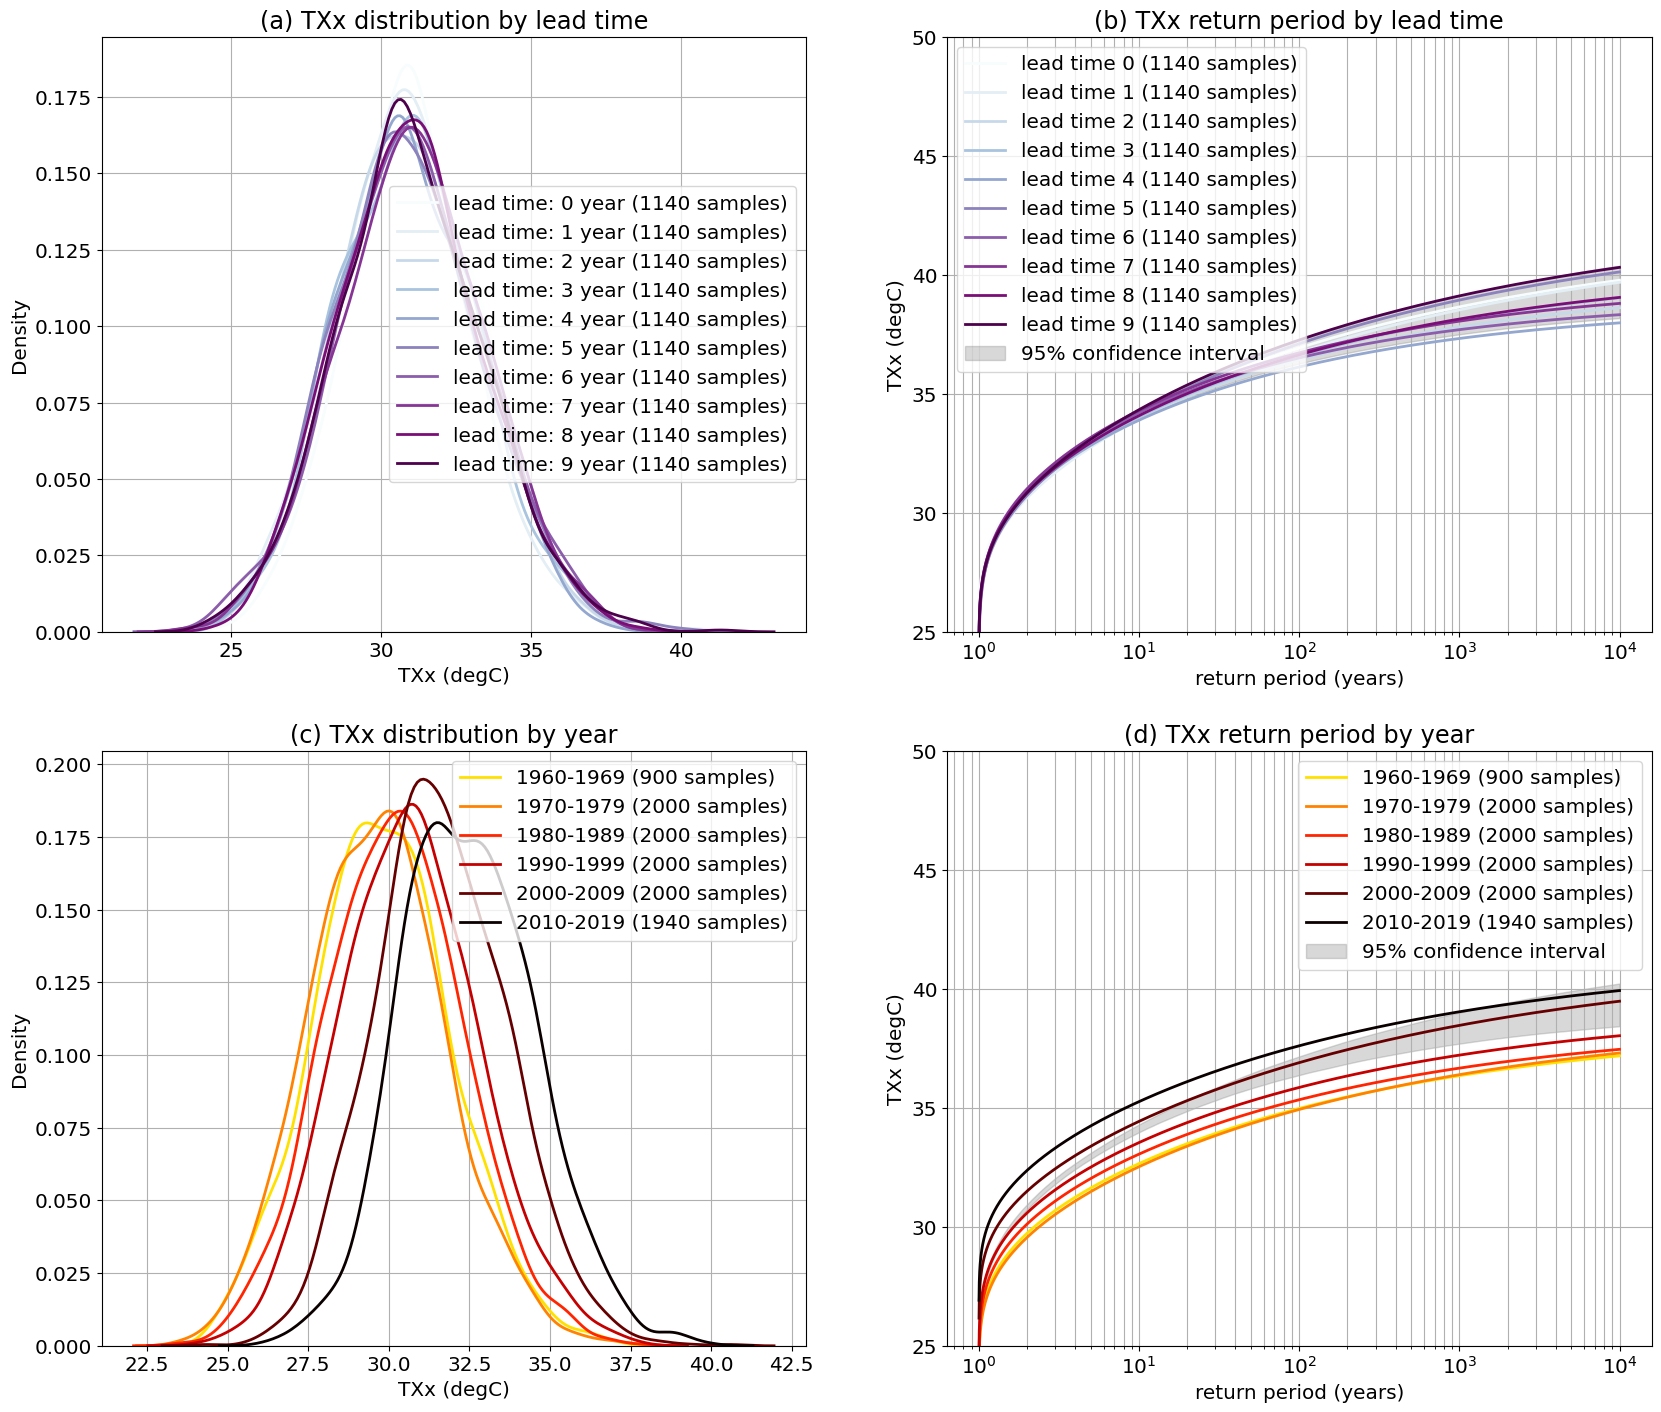

In [13]:
stability.create_plot(
    model_ds[var],
    'TXx',
    [1960, 1970, 1980, 1990, 2000, 2010],
    uncertainty=True,
    return_method='gev',
    units='TXx (degC)',
    ylim=(25, 50),
)

#### Independence

In [13]:
independence_ds = independence.run_tests(model_ds[var])

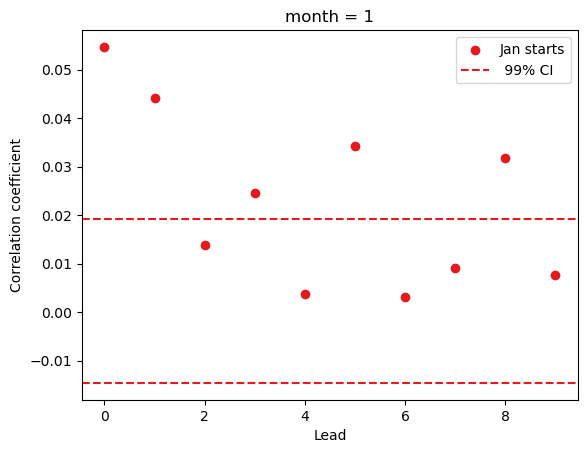

In [15]:
independence.point_plot(
    independence_ds,
    confidence_interval=0.99,
)

In [14]:
min_lead = 2

Drop lead times that aren't independent...

In [15]:
model_da_indep = model_ds[var].where(model_ds['lead_time'] >= min_lead)
model_da_indep = model_da_indep.dropna('lead_time')

In [16]:
model_da_indep_stacked = model_da_indep.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

In [17]:
model_da_indep_detrended, model_da_indep_stacked_detrended, linear_data = detrend_model(model_da_indep_stacked, pivot_year=2021)

[ 6.92519656e-02 -1.07191242e+02]


In [18]:
model_da_indep_detrended = model_da_indep_detrended.compute()

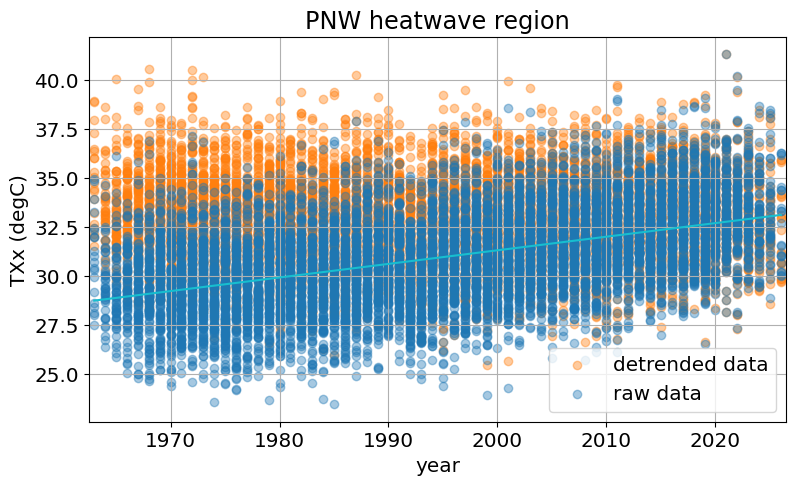

In [19]:
fig, ax = plt.subplots(figsize=[9, 5])
years = model_da_indep_stacked['time'].dt.year.values
unique_years = np.unique(model_da_indep_stacked.time.dt.year.values)

plt.plot(unique_years, linear_data, color='tab:cyan')
plt.scatter(
    years,
    model_da_indep_stacked_detrended.values,
    marker='o',
    color='tab:orange',
    alpha=0.4,
    label='detrended data'
)
plt.scatter(
    years,
    model_da_indep_stacked.values,
    marker='o',
    color='tab:blue',
    alpha=0.4,
    label='raw data'
)
plt.xlim(unique_years[0] - 0.5, unique_years[-1] + 0.5)
plt.title('PNW heatwave region')
plt.ylabel('TXx (degC)')
plt.xlabel('year')
plt.legend()
plt.grid()
plt.show()

#### Bias correction

In [20]:
correction_method = 'additive'

In [21]:
bias = bias_correction.get_bias(
    model_da_indep,
    obs_ds[var],
    correction_method,
    time_rounding='A',
    time_period=baseline_period
)
print(bias)

<xarray.DataArray 'tasmax' (month: 1)> Size: 8B
dask.array<subtract, shape=(1,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * month    (month) int64 8B 1
Attributes:
    standard_name:           air_temperature
    long_name:               Daily Maximum Near-Surface Air Temperature
    comment:                 maximum near-surface (usually, 2 meter) air temp...
    units:                   °C
    original_name:           STMX
    cell_methods:            area: mean time: maximum
    cell_measures:           area: areacella
    history:                 2019-06-18T21:25:55Z altered by CMOR: Treated sc...
    units_metadata:          temperature: unknown
    climatological_period:   ['1970-01-01', '2018-12-30']
    bias_correction_method:  additive
    bias_correction_period:  1970-01-01-2018-12-30


In [22]:
bias.values

array([-0.0481839])

In [23]:
model_da_bc = bias_correction.remove_bias(model_da_indep, bias, correction_method)

In [24]:
model_da_bc = model_da_bc.compute()

In [25]:
model_da_bc_stacked = model_da_bc.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

In [26]:
model_da_bc_detrended, model_da_bc_stacked_detrended, linear_data = detrend_model(model_da_bc_stacked, pivot_year=2021)

[ 6.92519656e-02 -1.07143058e+02]


#### Similarity testing

In [27]:
model_da_indep_stacked

<xarray.DataArray 'tasmax' (sample: 9120)> Size: 73kB
array([29.93321926, 32.39788201, 29.66273739, ..., 31.18728363,
       36.84563057, 33.45002311], shape=(9120,))
Coordinates:
    event_time  (sample) <U10 365kB '1963-09-05' '1964-07-17' ... '2026-08-03'
    time        (sample) object 73kB 1963-01-01 00:00:00 ... 2026-01-01 00:00:00
  * sample      (sample) object 73kB MultiIndex
  * ensemble    (sample) int64 73kB 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * init_date   (sample) object 73kB 1961-01-01 00:00:00 ... 2017-01-01 00:00:00
  * lead_time   (sample) int64 73kB 2 3 4 5 6 7 8 9 2 3 ... 8 9 2 3 4 5 6 7 8 9
Attributes:
    standard_name:   air_temperature
    long_name:       Daily Maximum Near-Surface Air Temperature
    comment:         maximum near-surface (usually, 2 meter) air temperature ...
    units:           °C
    original_name:   STMX
    cell_methods:    area: mean time: maximum
    cell_measures:   area: areacella
    history:         2019-06-18T21:25:55Z altered by CMOR: Treated scalar dim...
    units_metadata:  temperature: unknown

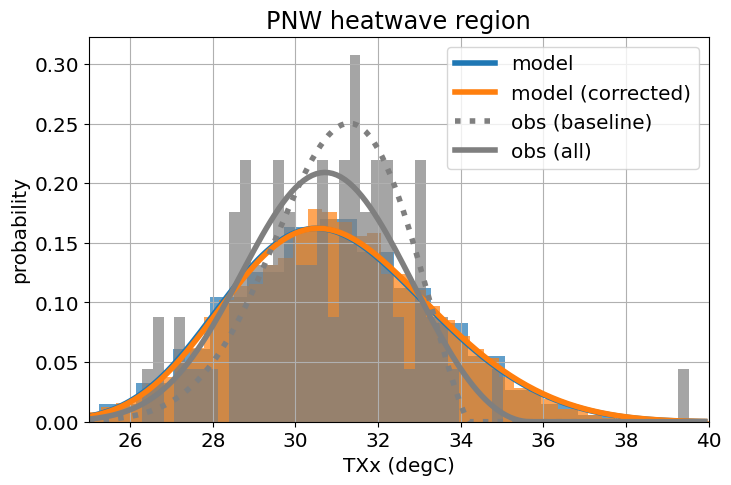

In [28]:
fig, ax = plt.subplots(figsize=[8, 5])
xvals = np.arange(25, 40, 0.1)

model_da_indep.plot.hist(bins=20, density=True, alpha=0.7, facecolor='tab:blue')
model_raw_shape, model_raw_loc, model_raw_scale = eva.fit_gev(model_da_indep_stacked.values)
model_raw_pdf = gev.pdf(xvals, model_raw_shape, model_raw_loc, model_raw_scale)
plt.plot(xvals, model_raw_pdf, color='tab:blue', linewidth=4.0, label='model')

model_da_bc.plot.hist(bins=50, density=True, alpha=0.7, facecolor='tab:orange')
model_bc_shape, model_bc_loc, model_bc_scale = eva.fit_gev(model_da_bc_stacked.values)
model_bc_pdf = gev.pdf(xvals, model_bc_shape, model_bc_loc, model_bc_scale)
plt.plot(xvals, model_bc_pdf, color='tab:orange', linewidth=4.0, label='model (corrected)')

#obs_ds_baseline[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:grey', alpha=0.7)
obs_baseline_shape, obs_baseline_loc, obs_baseline_scale = eva.fit_gev(obs_ds_baseline[var].values)
obs_baseline_pdf = gev.pdf(xvals, obs_baseline_shape, obs_baseline_loc, obs_baseline_scale)
plt.plot(xvals, obs_baseline_pdf, color='tab:gray', linewidth=4.0, linestyle=':', label='obs (baseline)')

obs_ds[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:gray', alpha=0.7)
obs_shape, obs_loc, obs_scale = eva.fit_gev(obs_ds[var].values)
obs_pdf = gev.pdf(xvals, obs_shape, obs_loc, obs_scale)
plt.plot(xvals, obs_pdf, color='tab:gray', linewidth=4.0, label='obs (all)')

plt.xlabel('TXx (degC)')
plt.ylabel('probability')
plt.title('PNW heatwave region')
plt.xlim(25, 40)
plt.legend()
plt.grid()
#plt.savefig(
#    'distribution.png',
#    bbox_inches='tight',
#    facecolor='white',
#    dpi=200
#)
plt.show()

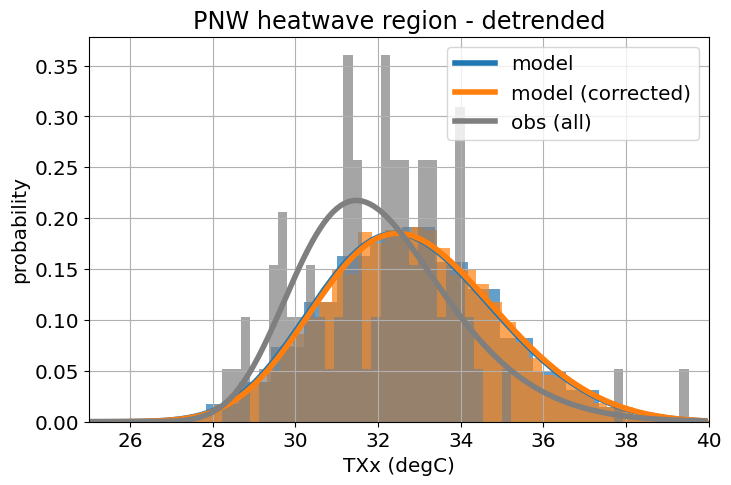

In [29]:
fig, ax = plt.subplots(figsize=[8, 5])
xvals = np.arange(25, 40, 0.1)

model_da_indep_detrended.plot.hist(bins=20, density=True, alpha=0.7, facecolor='tab:blue')
model_raw_shape, model_raw_loc, model_raw_scale = eva.fit_gev(model_da_indep_stacked_detrended.values)
model_raw_pdf = gev.pdf(xvals, model_raw_shape, model_raw_loc, model_raw_scale)
plt.plot(xvals, model_raw_pdf, color='tab:blue', linewidth=4.0, label='model')

model_da_bc_detrended.plot.hist(bins=50, density=True, alpha=0.7, facecolor='tab:orange')
model_bc_shape, model_bc_loc, model_bc_scale = eva.fit_gev(model_da_bc_stacked_detrended.values)
model_bc_pdf = gev.pdf(xvals, model_bc_shape, model_bc_loc, model_bc_scale)
plt.plot(xvals, model_bc_pdf, color='tab:orange', linewidth=4.0, label='model (corrected)')

#obs_ds_baseline[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:grey', alpha=0.7)
#obs_baseline_shape, obs_baseline_loc, obs_baseline_scale = eva.fit_gev(obs_da_baseline_detrended.values)
#obs_baseline_pdf = gev.pdf(xvals, obs_baseline_shape, obs_baseline_loc, obs_baseline_scale)
#plt.plot(xvals, obs_baseline_pdf, color='tab:gray', linewidth=4.0, linestyle=':', label='obs (baseline)')

obs_da_detrended.plot.hist(ax=ax, bins=50, density=True, facecolor='tab:gray', alpha=0.7)
obs_shape, obs_loc, obs_scale = eva.fit_gev(obs_da_detrended.values)
obs_pdf = gev.pdf(xvals, obs_shape, obs_loc, obs_scale)
plt.plot(xvals, obs_pdf, color='tab:gray', linewidth=4.0, label='obs (all)')

plt.xlabel('TXx (degC)')
plt.ylabel('probability')
plt.title('PNW heatwave region - detrended')
plt.xlim(25, 40)
plt.legend()
plt.grid()
#plt.savefig(
#    'distribution.png',
#    bbox_inches='tight',
#    facecolor='white',
#    dpi=200
#)
plt.show()

INFO:root:mean: Obs = 32.04770177300941, Model 95% CI =32.30403526628238 to 33.21337995290669
INFO:root:standard deviation: Obs = 1.8673311122581864, Model 95% CI =1.7687656747431852 to 2.3610760499385224
INFO:root:skew: Obs = 0.6937577849233526, Model 95% CI =-0.3598357038459781 to 0.661478119056707
INFO:root:kurtosis: Obs = 2.2076630095468914, Model 95% CI =-0.7876138323852546 to 1.1636957326031603
INFO:root:GEV shape: Obs = 0.11600022891091236, Model 95% CI =0.0972645978389397 to 0.4046036047875083
INFO:root:GEV location: Obs = 31.26462626963911, Model 95% CI =31.51666773164027 to 32.463489451775274
INFO:root:GEV scale: Obs = 1.703271088074413, Model 95% CI =1.6940929798994648 to 2.3526210830244945
INFO:root:mean: Obs = 32.04770177300941, Bias corrected model 95% CI =32.35720931865506 to 33.25313263126836
INFO:root:standard deviation: Obs = 1.8673311122581864, Bias corrected model 95% CI =1.7610439374519509 to 2.4039139346588705
INFO:root:skew: Obs = 0.6937577849233526, Bias correct

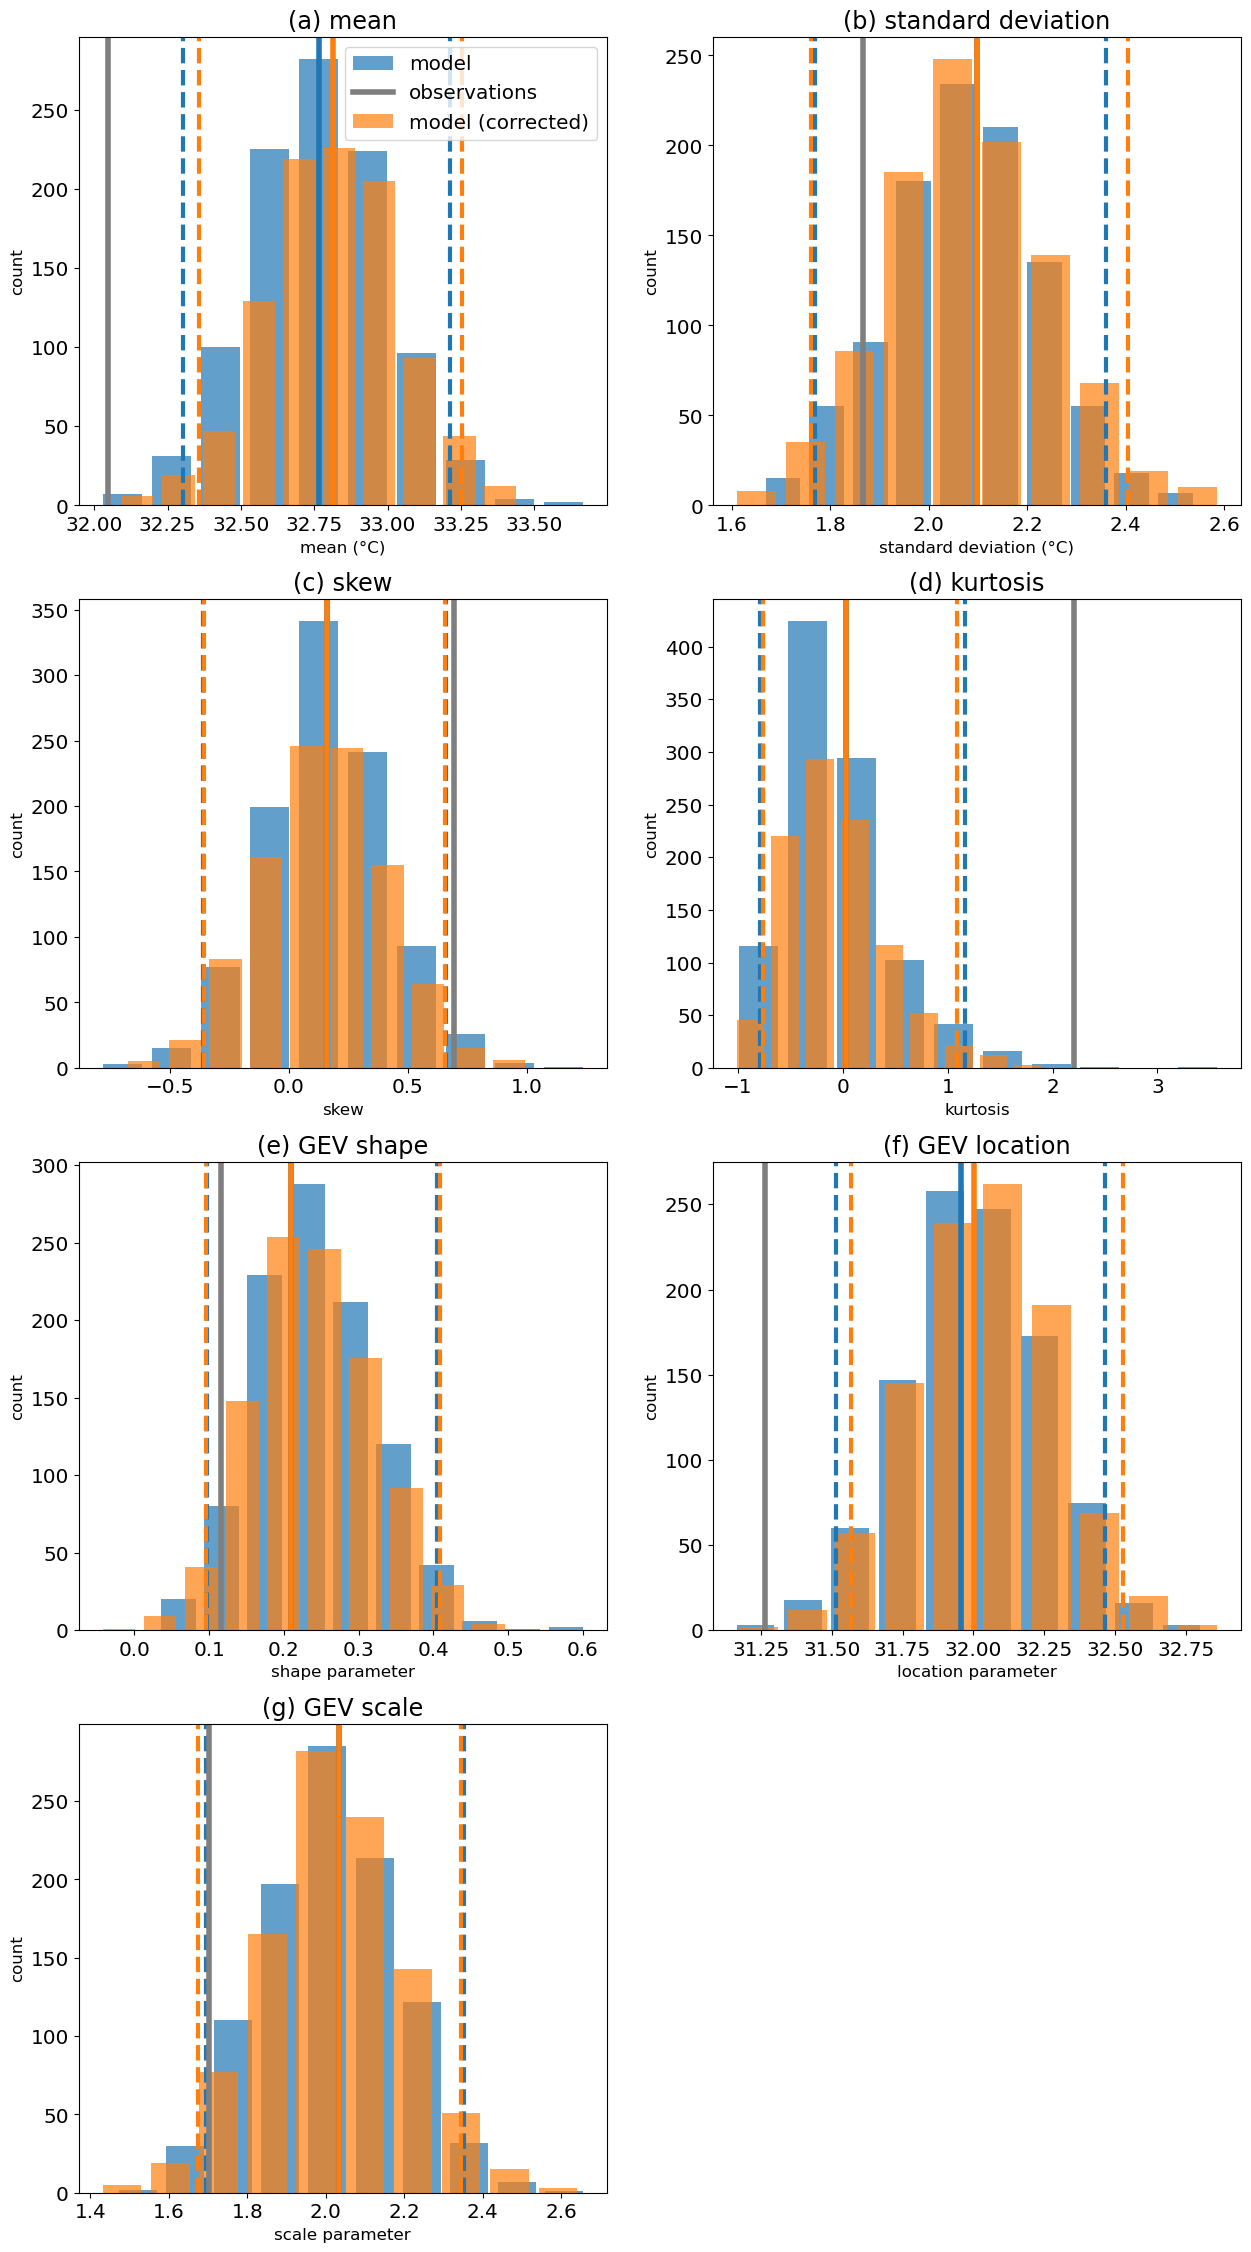

In [30]:
moments.create_plot(
    model_da_indep_detrended,
    obs_da_detrended,
    da_bc_fcst=model_da_bc_detrended,
)

In [31]:
similarity_ds = similarity.similarity_tests(model_da_indep_detrended, obs_da_detrended)
print('KS score:', similarity_ds['ks_statistic'].values)
print('KS p-value:', similarity_ds['ks_pval'].values)
print('AD score:', similarity_ds['ad_statistic'].values)
print('AD p-value:', similarity_ds['ad_pval'].values)

KS score: 0.20206293
KS p-value: 0.0015858497
AD score: 6.912718
AD p-value: 0.001


In [32]:
similarity_bc_ds = similarity.similarity_tests(model_da_bc_detrended, obs_da_detrended)
print('KS score:', similarity_bc_ds['ks_statistic'].values)
print('KS p-value:', similarity_bc_ds['ks_pval'].values)
print('AD score:', similarity_bc_ds['ad_statistic'].values)
print('AD p-value:', similarity_bc_ds['ad_pval'].values)

KS score: 0.20886117
KS p-value: 0.00097288797
AD score: 7.8436813
AD p-value: 0.001


p > 0.05 means that the null hypothesis (that the two samples are from the same population) cannot be rejected.

#### Process assessment

In [ ]:
#model_da_indep_stacked_df = model_da_indep_stacked.to_dataframe()

In [ ]:
#model_da_indep_stacked_df.sort_values(by=[var], ascending=False)

In [ ]:
#process_utils.plot_event_seasonality(model_da_indep_stacked_df)

In [ ]:
#process_utils.plot_circulation(
#    model_da_indep_stacked_df,
#    event_var=var,
#    top_n_events=3,
#    event_duration=5,
#    infile_list='/home/599/dbi599/unseen-projects/file_lists/CanESM5_dcppA-hindcast_tasmax_files.txt',
#    color_var=var,
#    contour_var='psl',
#    color_levels=[0, 30, 60, 90, 120, 150, 180, 210],
#    init_year_offset=0,
#)

## Results

#### Empirical
Uses the bias corrected, linearly detrended (pivot year 2021) model data.

In [33]:
n_exceedances = np.sum(model_da_bc_stacked_detrended.values > obs_max_event)
n_samples = len(model_da_bc_stacked_detrended.values)
empirical_return_period = n_samples / n_exceedances
model_max = model_da_bc_stacked_detrended.values.max()

In [34]:
print(f'The highest TXx value in the model is {model_max:.2f}C.')
print(f'Of the {n_samples} model TXx values, {n_exceedances} exceed the observed value in 2021 of {obs_max_event:.2f}C.')
print(f'The empirical return period of a {obs_max_event:.2f}C event is {empirical_return_period:.0f} years.')

The highest TXx value in the model is 41.35C.
Of the 9120 model TXx values, 15 exceed the observed value in 2021 of 39.51C.
The empirical return period of a 39.51C event is 608 years.


#### Stationary GEV
Uses the bias corrected, linearly detrended (pivot year 2021) model data.

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


1169 year return period
95% CI: 789-1725 years


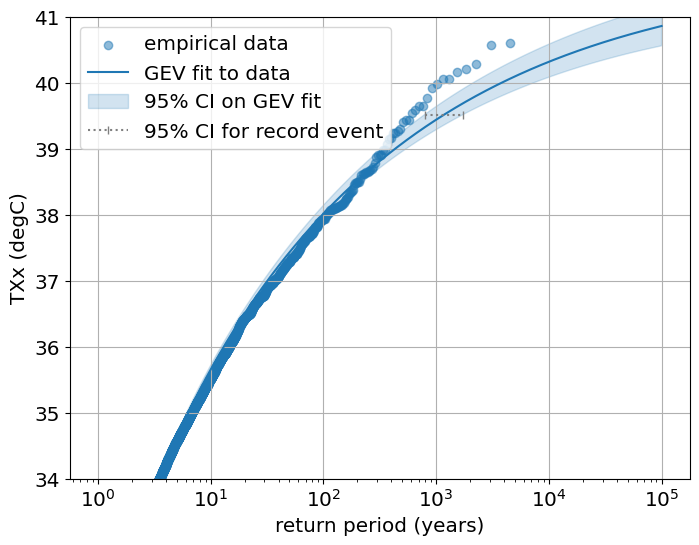

In [35]:
fig = plt.figure(figsize=[8, 6])
ax = fig.add_subplot()
eva.plot_gev_return_curve(
    ax,
    model_da_bc_stacked_detrended.values,
    obs_max_event,
    max_return_period=5,
    n_bootstraps=10,
    direction="exceedance",
    ylabel='TXx (degC)',
    ylim=(34, 41),
)
plt.show()

#### Non-stationary GEV

Uses the bias corrected model data (i.e. no linear detrending).

In [36]:
#AIC/BIC/LRT test to see if it's worth modelling the scale trend
daparams_list = [eva.fit_gev(
    model_da_bc_stacked,
    core_dim="sample",
    stationary=False,
    covariate=model_da_bc_stacked['time'].dt.year,
    use_basinhopping=True,
    scale1=scale1,
).values for scale1 in [0, None]]

data = model_da_bc_stacked.values
covariate = model_da_bc_stacked['time'].dt.year.values
nll_1 = eva._gev_nllf(daparams_list[0], data, covariate)
nll_2 = eva._gev_nllf(daparams_list[1], data, covariate)
result = eva.check_gev_relative_fit(data, nll_1, nll_2, test='bic', n_params=[4,5])
print('better to include the scale trend parameter:', result)

/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in power
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: overflow encountered in power
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: divide by zero encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in power
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.

better to include the scale trend parameter: False


In [37]:
daparams = eva.fit_gev(
    model_da_bc_stacked,
    core_dim="sample",
    stationary=False,
    covariate=model_da_bc_stacked['time'].dt.year,
    use_basinhopping=True,
    scale1=None,
)

/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in power
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: divide by zero encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: overflow encountered in power
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [38]:
for param, value in zip(daparams.dparams.values, daparams.values):
    print(param, value)

c 0.20915859681272225
location_0 -109.08949428183067
location_1 0.06982083716245135
scale_0 2.0352228386507187
scale_1 0.0


In [39]:
return_period = float(eva.get_return_period(obs_max_event, daparams, covariate=2021).values)

In [40]:
print(f'The return period of a {obs_max_event:.2f}C event in 2021 is {return_period:.0f} years.')

The return period of a 39.51C event in 2021 is 1136 years.


In [41]:
for year in np.arange(1960, 2030):
    rp = float(eva.get_return_period(obs_max_event, daparams, covariate=year).values)
    print(f'The return period of a {obs_max_event:.2f}C event in {year} is {rp:.0f} years.')

The return period of a 39.51C event in 1960 is inf years.
The return period of a 39.51C event in 1961 is inf years.
The return period of a 39.51C event in 1962 is inf years.
The return period of a 39.51C event in 1963 is inf years.
The return period of a 39.51C event in 1964 is inf years.
The return period of a 39.51C event in 1965 is inf years.
The return period of a 39.51C event in 1966 is inf years.
The return period of a 39.51C event in 1967 is inf years.
The return period of a 39.51C event in 1968 is inf years.
The return period of a 39.51C event in 1969 is inf years.
The return period of a 39.51C event in 1970 is inf years.
The return period of a 39.51C event in 1971 is inf years.
The return period of a 39.51C event in 1972 is inf years.
The return period of a 39.51C event in 1973 is inf years.
The return period of a 39.51C event in 1974 is inf years.
The return period of a 39.51C event in 1975 is inf years.
The return period of a 39.51C event in 1976 is inf years.
The return per